# Transaction Accuracy Check

This notebook checks selected data accuracy rules for `transaction.csv`.

In [113]:
import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

FILE_PATH = "transaction.csv"
df = pd.read_csv(FILE_PATH)
print(f"Loaded: {FILE_PATH} | shape={df.shape}")
print("Columns:", list(df.columns))

Loaded: transaction.csv | shape=(10103, 6)
Columns: ['status', 'time', 'card_type', 'city', 'amount', 'id']


In [114]:
# Amount accuracy check
# Rule: amount must be numeric and > 0

AMOUNT_COLUMN = "amount"

if AMOUNT_COLUMN not in df.columns:
    raise ValueError(f"Column '{AMOUNT_COLUMN}' not found.")

amount_txt = df[AMOUNT_COLUMN].astype("string").str.strip()
one_hundred = amount_txt.str.lower().eq("one hundred").fillna(False)
amount_txt_fixed = amount_txt.where(~one_hundred, "100")
amount_num = pd.to_numeric(amount_txt_fixed, errors="coerce")
amount_num = amount_num.abs()

null_mask = amount_txt.isna() | (amount_txt == "")
non_numeric_mask = amount_num.isna() & ~null_mask
valid_mask = amount_num.notna() & (amount_num > 0)
invalid_mask = (~valid_mask) & (~null_mask)  # includes non-numeric and <= 0

amount_status = pd.Series("invalid", index=df.index, dtype="string")
amount_status[null_mask] = "NULL"
amount_status[valid_mask] = "valid"

amount_check = df[[AMOUNT_COLUMN]].copy()
amount_check["amount_accuracy_status"] = amount_status
amount_check["amount_non_numeric"] = non_numeric_mask

summary = (
    amount_check["amount_accuracy_status"]
    .value_counts(dropna=False)
    .reindex(["valid", "invalid", "NULL"], fill_value=0)
    .rename_axis("status")
    .reset_index(name="count")
)
summary["pct_of_total_rows"] = (summary["count"] / len(df) * 100).round(2)

amount_before_abs = pd.to_numeric(amount_txt_fixed, errors="coerce")
neg_before_abs = int(((amount_before_abs < 0) & amount_before_abs.notna()).sum())

detail = pd.DataFrame([
    {"metric": "Non-numeric amount rows", "value": int(non_numeric_mask.sum())},
    {"metric": "Negative amounts (converted to positive)", "value": neg_before_abs},
])

print("Amount accuracy summary:")
display(summary)
print("Amount invalid detail:")
display(detail)

print("Invalid amount examples:")
display(amount_check[amount_check["amount_accuracy_status"] == "invalid"].head(50))

Amount accuracy summary:


,status,count,pct_of_total_rows
0,valid,8883,87.92
1,invalid,1218,12.06
2,NULL,2,0.02


Amount invalid detail:


,metric,value
0,Non-numeric amount rows,1
1,Numeric but < 0 rows,1217


Invalid amount examples:


,amount,amount_accuracy_status,amount_non_numeric
0,-5000,invalid,False
15,-5000,invalid,False
16,-5000,invalid,False
18,one hundred,invalid,True
20,-999999,invalid,False
35,-1,invalid,False
42,-999999,invalid,False
46,-5000,invalid,False
53,-5000,invalid,False
64,-999999,invalid,False


In [115]:
# Datetime format + impossible date/time check
# Accepted formats:
# 1) YYYY-MM-DD HH:MM:SS      e.g., 2025-09-19 12:12:00
# 2) HH:MM YYYY-MM-DD         e.g., 07:32 2025-09-20
# Invalid examples: 2030-13-33 10:00:00, 99:99 2025-09-20

TIME_COLUMN = "time"

time_raw = df[TIME_COLUMN].astype("string").str.strip()
null_mask = time_raw.isna() | (time_raw == "")

# Format 1 check
fmt1_regex = r"\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}"
fmt1_mask = time_raw.str.fullmatch(fmt1_regex, na=False)
fmt1_parsed = pd.to_datetime(time_raw, format="%Y-%m-%d %H:%M:%S", errors="coerce")
fmt1_valid = fmt1_mask & fmt1_parsed.notna()

# Format 2 check
fmt2_regex = r"\d{2}:\d{2} \d{4}-\d{2}-\d{2}"
fmt2_mask = time_raw.str.fullmatch(fmt2_regex, na=False)
fmt2_parsed = pd.to_datetime(time_raw, format="%H:%M %Y-%m-%d", errors="coerce")
fmt2_valid = fmt2_mask & fmt2_parsed.notna()

valid_mask = fmt1_valid | fmt2_valid
impossible_mask = (~null_mask) & (fmt1_mask | fmt2_mask) & (~valid_mask)

dt_check = df[[TIME_COLUMN]].copy()
dt_check["matched_format"] = "invalid_format"
dt_check.loc[fmt1_valid, "matched_format"] = "YYYY-MM-DD HH:MM:SS"
dt_check.loc[fmt2_valid, "matched_format"] = "HH:MM YYYY-MM-DD"

dt_check["datetime_status"] = "invalid"
dt_check.loc[null_mask, "datetime_status"] = "NULL"
dt_check.loc[valid_mask, "datetime_status"] = "valid"
dt_check.loc[impossible_mask, "datetime_status"] = "impossible_date_or_time"

summary = (
    dt_check["datetime_status"]
    .value_counts(dropna=False)
    .reindex(["valid", "impossible_date_or_time", "invalid", "NULL"], fill_value=0)
    .rename_axis("status")
    .reset_index(name="count")
)
summary["pct_of_total_rows"] = (summary["count"] / len(df) * 100).round(2)

display(summary)

format_split = (
    dt_check.loc[dt_check["datetime_status"] == "valid", "matched_format"]
    .value_counts()
    .rename_axis("valid_format")
    .reset_index(name="count")
)
print("Valid rows by format:")
display(format_split)

print("Impossible date/time examples:")
display(dt_check[dt_check["datetime_status"] == "impossible_date_or_time"].head(50))

print("Other invalid-format examples:")
display(dt_check[dt_check["datetime_status"] == "invalid"].head(50))

,status,count,pct_of_total_rows
0,valid,10076,99.73
1,impossible_date_or_time,14,0.14
2,invalid,5,0.05
3,NULL,8,0.08


Valid rows by format:


,valid_format,count
0,YYYY-MM-DD HH:MM:SS,10000
1,HH:MM YYYY-MM-DD,76


Impossible date/time examples:


,time,matched_format,datetime_status
13,25:61 2025-09-11,invalid_format,impossible_date_or_time
15,25:61 2025-09-11,invalid_format,impossible_date_or_time
18,99:99 2025-13-40,invalid_format,impossible_date_or_time
33,99:99 2025-13-40,invalid_format,impossible_date_or_time
42,99:99 2025-13-40,invalid_format,impossible_date_or_time
44,07:99 2025-09-11,invalid_format,impossible_date_or_time
46,25:61 2025-09-11,invalid_format,impossible_date_or_time
51,00:61 2025-09-11,invalid_format,impossible_date_or_time
59,25:61 2025-09-11,invalid_format,impossible_date_or_time
69,25:61 2025-09-11,invalid_format,impossible_date_or_time


Other invalid-format examples:


,time,matched_format,datetime_status
3,03-00-2025 09-11,invalid_format,invalid
28,12:00,invalid_format,invalid
32,3pm 2025/09/11,invalid_format,invalid
55,03-00-2025 09-11,invalid_format,invalid
98,3pm 2025/09/11,invalid_format,invalid


## Time Visualizations (3 Charts)

- **Boxplot**: best for outlier detection
- **Histogram**: shows time-value distribution
- **Scatter**: shows spread across records

Rows with collected hour: 10090
Hours > 24 (outliers): 12


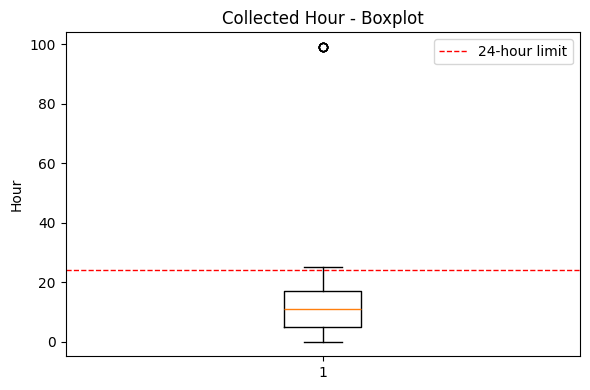

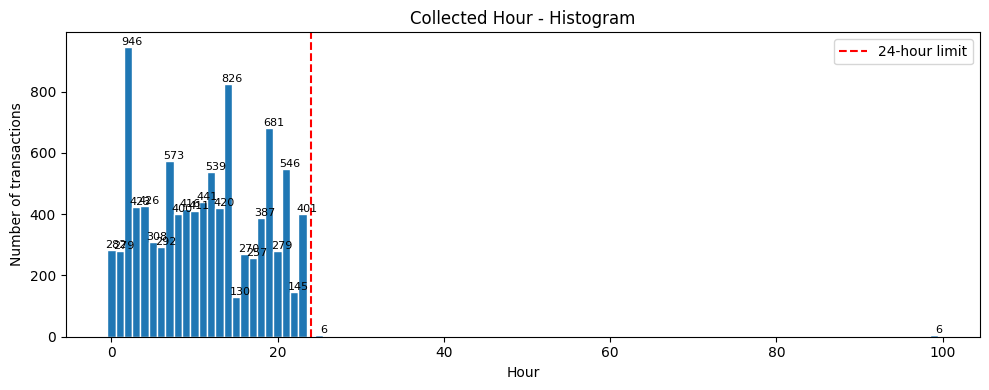

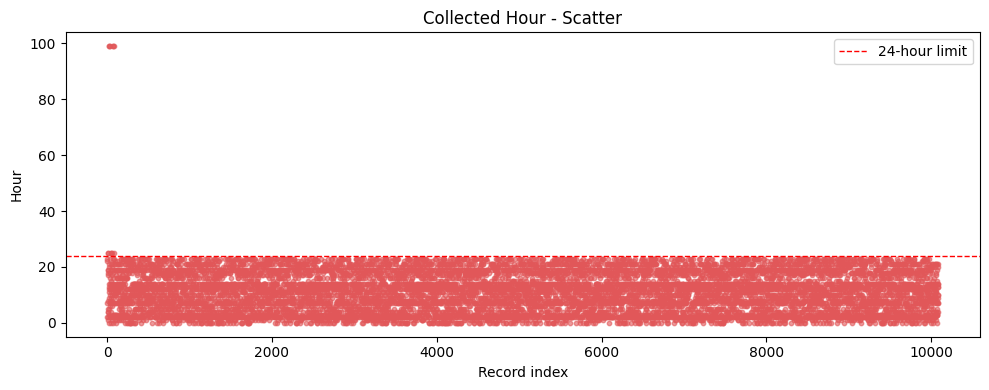

In [116]:
# Hour-only extraction (ignore minutes/seconds), then plot 3 charts
# Examples:
# - "25:61 2025-09-11" -> hour = 25
# - "2025-09-02 16:40:00" -> hour = 16

import pandas as pd
import matplotlib.pyplot as plt

TIME_COLUMN = "time"
time_raw = df[TIME_COLUMN].astype("string").str.strip()

# Pattern A: HH:MM YYYY-MM-DD  -> take first HH
h1 = time_raw.str.extract(r"^(\d{2}):\d{2}\s\d{4}-\d{2}-\d{2}$", expand=False)

# Pattern B: YYYY-MM-DD HH:MM:SS -> take HH after date
h2 = time_raw.str.extract(r"^\d{4}-\d{2}-\d{2}\s(\d{2}):\d{2}:\d{2}$", expand=False)

hour_collected = pd.to_numeric(h1.fillna(h2), errors="coerce")
plot_hour = pd.to_numeric(h1.fillna(h2), errors="coerce").dropna()

print(f"Rows with collected hour: {len(plot_hour)}")
print(f"Hours > 24 (outliers): {(plot_hour > 24).sum()}")

# 1) Boxplot
plt.figure(figsize=(6, 4))
plt.boxplot(plot_hour, vert=True)
plt.axhline(24, color="red", linestyle="--", linewidth=1, label="24-hour limit")
plt.title("Collected Hour - Boxplot")
plt.ylabel("Hour")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

# 2) Histogram (hours vs counts)
plt.figure(figsize=(10, 4))
bins = range(int(plot_hour.min()), int(plot_hour.max()) + 2)
counts, edges, patches = plt.hist(plot_hour, bins=bins, edgecolor="white", align="left")
plt.axvline(24, color="red", linestyle="--", label="24-hour limit")
plt.xlabel("Hour")
plt.ylabel("Number of transactions")
plt.title("Collected Hour - Histogram")
plt.legend()
# label each bar
for c, left, right in zip(counts, edges[:-1], edges[1:]):
    if c > 0:
        x = (left + right) / 2
        plt.text(x, c, str(int(c)), ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

# 3) Scatter (hour spread)
plt.figure(figsize=(10, 4))
plt.scatter(range(len(plot_hour)), plot_hour, s=10, alpha=0.6, color="#e15759")
plt.axhline(24, color="red", linestyle="--", linewidth=1, label="24-hour limit")
plt.title("Collected Hour - Scatter")
plt.xlabel("Record index")
plt.ylabel("Hour")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Amount Accuracy Charts 

Two charts:
1. Combined **bar + line** chart for amount accuracy summary
2. **Bar chart** for invalid amount detail

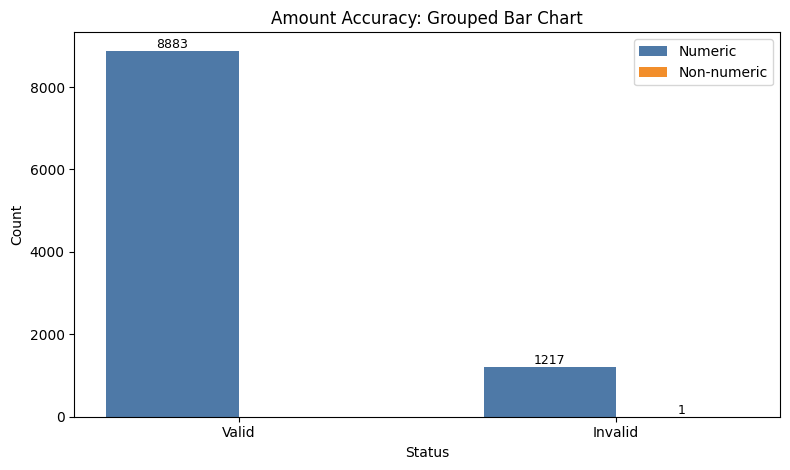

In [124]:
# Grouped bar chart: Valid vs Invalid (numeric / non-numeric)
# Based on your provided counts

import matplotlib.pyplot as plt
import numpy as np

# Counts
valid_count = 8883
invalid_numeric_count = 1217   # numeric but < 0
invalid_non_numeric_count = 1  # non-numeric

# Build grouped data
categories = ["Valid", "Invalid"]
numeric_series = [valid_count, invalid_numeric_count]
non_numeric_series = [0, invalid_non_numeric_count]  # valid has no non-numeric split

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4.8))

bars1 = ax.bar(x - width/2, numeric_series, width, label="Numeric", color="#4e79a7")
bars2 = ax.bar(x + width/2, non_numeric_series, width, label="Non-numeric", color="#f28e2b")

ax.set_title("Amount Accuracy: Grouped Bar Chart")
ax.set_xlabel("Status")
ax.set_ylabel("Count")
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

# Labels on bars
for bars in [bars1, bars2]:
    for b in bars:
        h = b.get_height()
        if h > 0:
            ax.text(b.get_x() + b.get_width()/2, h, f"{int(h)}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

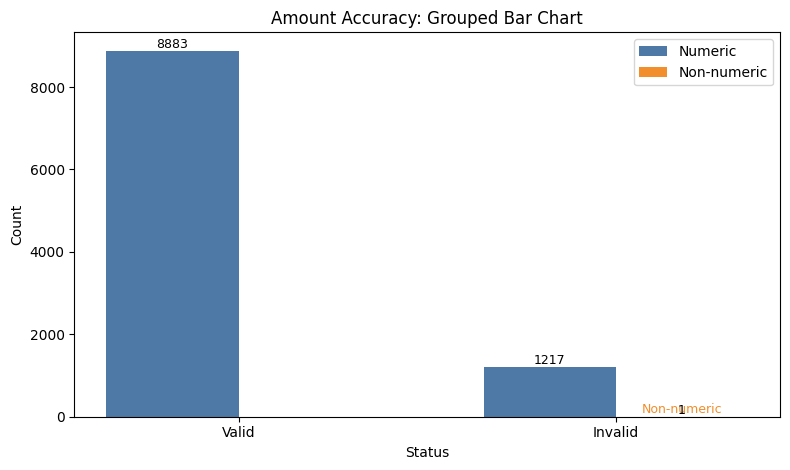

In [125]:
# Grouped bar chart (updated): add "Numeric" and "Non-numeric" text at Invalid part
import matplotlib.pyplot as plt
import numpy as np

valid_count = 8883
invalid_numeric_count = 1217
invalid_non_numeric_count = 1

categories = ["Valid", "Invalid"]
numeric_series = [valid_count, invalid_numeric_count]
non_numeric_series = [0, invalid_non_numeric_count]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4.8))
bars1 = ax.bar(x - width/2, numeric_series, width, label="Numeric", color="#4e79a7")
bars2 = ax.bar(x + width/2, non_numeric_series, width, label="Non-numeric", color="#f28e2b")

ax.set_title("Amount Accuracy: Grouped Bar Chart")
ax.set_xlabel("Status")
ax.set_ylabel("Count")
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

# Words at the Invalid part
invalid_x = x[1]
text_y = max(1, invalid_numeric_count * 0.02)
ax.text(invalid_x - width/2, text_y, "Numeric", ha="center", va="bottom", fontsize=9, color="#4e79a7")
ax.text(invalid_x + width/2, text_y, "Non-numeric", ha="center", va="bottom", fontsize=9, color="#f28e2b")

# Value labels on bars
for bars in [bars1, bars2]:
    for b in bars:
        h = b.get_height()
        if h > 0:
            ax.text(b.get_x() + b.get_width()/2, h, f"{int(h)}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

IQR Outlier Detection Summary
Q1: 100.5
Q3: 914465.0
IQR: 914364.5
Lower bound: -1371446.25
Upper bound: 2286011.75
Outlier rows: 299
Non-outlier rows: 9801

Outlier sample:


,status,time,card_type,city,amount,id,amount_num
3,failed,03-00-2025 09-11,Discover,Qom,9999999999,4,1.000000e+10
5,Success,02:24 2025-09-04,Master Card,tehr@n,9999999999,6,1.000000e+10
74,fail,18:00 2025-09-18,MasterCard,Tehran,9999999999,75,1.000000e+10
102,success,01:00 2025-09-11,Visa,THR,99999999,4,1.000000e+08
127,success,2025-09-12 16:40:00,Vsa,Shiraz,9999999999.0,31,1.000000e+10
138,success,2025-09-12 19:51:00,Vsa,THR,9999999999.0,64,1.000000e+10
156,success,2025-09-25 07:32:00,MasterCard,Ahvaz,9999999999.0,66,1.000000e+10
164,fail,2025-09-18 16:16:00,Vsa,Isfahan,9999999999.0,93,1.000000e+10
227,success,2025-09-28 21:23:00,Vsa,Tabriz,9999999999.0,82,1.000000e+10
236,fail,2025-09-09 08:08:00,Discover,Qom,9999999999.0,96,1.000000e+10


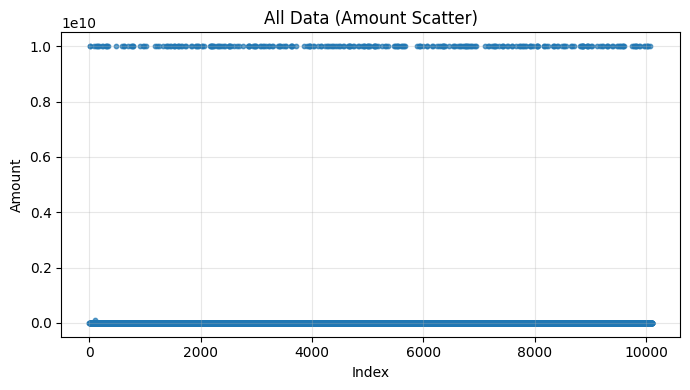

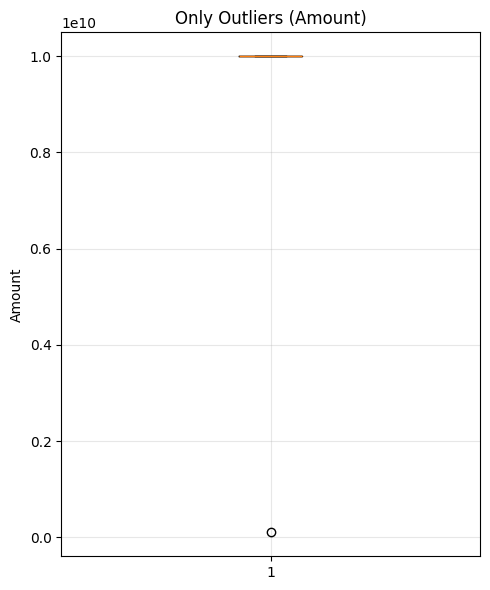

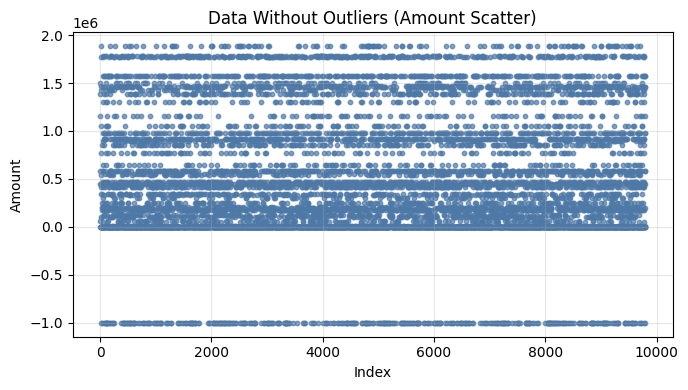

In [126]:
# Amount outlier detection (IQR method) + visualizations
# This uses the dataframe `df` already loaded in this notebook.

import pandas as pd
import matplotlib.pyplot as plt

# Ensure numeric amount
amount_num = pd.to_numeric(df["amount"], errors="coerce")
work = df.copy()
work["amount_num"] = amount_num

# Compute IQR bounds from non-null numeric values
q1 = work["amount_num"].quantile(0.25)
q3 = work["amount_num"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Split outliers and non-outliers
outliers = work[(work["amount_num"] < lower_bound) | (work["amount_num"] > upper_bound)]
non_outliers = work[(work["amount_num"] >= lower_bound) & (work["amount_num"] <= upper_bound)]

print("IQR Outlier Detection Summary")
print(f"Q1: {q1}")
print(f"Q3: {q3}")
print(f"IQR: {iqr}")
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")
print(f"Outlier rows: {len(outliers)}")
print(f"Non-outlier rows: {len(non_outliers)}")

print("\nOutlier sample:")
display(outliers[["status", "time", "card_type", "city", "amount", "id", "amount_num"]].head(50))

# 1) All data scatter
plt.figure(figsize=(7, 4))
plt.scatter(range(len(work)), work["amount_num"], s=10, alpha=0.7)
plt.title("All Data (Amount Scatter)")
plt.ylabel("Amount")
plt.xlabel("Index")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2) Outliers-only boxplot
if len(outliers) > 0:
    plt.figure(figsize=(5, 6))
    plt.boxplot(outliers["amount_num"].dropna())
    plt.title("Only Outliers (Amount)")
    plt.ylabel("Amount")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No outliers detected by IQR rule.")

# 3) Non-outliers scatter
plt.figure(figsize=(7, 4))
plt.scatter(range(len(non_outliers)), non_outliers["amount_num"], s=10, alpha=0.7, color="#4e79a7")
plt.title("Data Without Outliers (Amount Scatter)")
plt.ylabel("Amount")
plt.xlabel("Index")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Amount status vs outlier status table:


outlier_status,outlier,non_outlier,not_numeric_or_null
amount_status,,,
valid,299,7593,0
invalid,0,2208,1
NULL,0,0,2


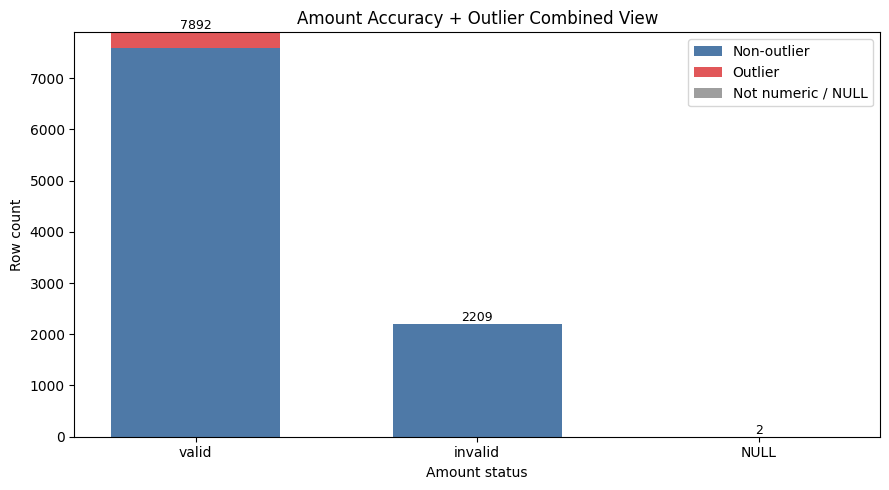

In [127]:
# Combined chart: Amount validity + Outlier status
# Produces a stacked bar chart showing, for each amount status,
# how many rows are outliers vs non-outliers.
#
# Cleaning: literal "one hundred" -> 100; negatives -> absolute value;
# IQR outliers are set to null for validity (still flagged as outlier below).

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

amount_txt = df["amount"].astype("string").str.strip()
one_hundred = amount_txt.str.lower().eq("one hundred").fillna(False)
amount_txt_fixed = amount_txt.where(~one_hundred, "100")

amount_num = pd.to_numeric(amount_txt_fixed, errors="coerce")
amount_num = amount_num.abs()

# IQR on positive amounts (after abs / text fix)
positive_amount = amount_num[amount_num > 0]
q1 = positive_amount.quantile(0.25)
q3 = positive_amount.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_mask = amount_num.notna() & ((amount_num < lower_bound) | (amount_num > upper_bound))
amount_clean = amount_num.copy()
amount_clean[outlier_mask] = np.nan

# Amount validity: valid = positive numeric and not an IQR outlier (outliers nulled)
null_mask = amount_txt.isna() | (amount_txt == "")
valid_mask = amount_clean.notna() & (amount_clean > 0)

amount_status = pd.Series("invalid", index=df.index, dtype="string")
amount_status[null_mask] = "NULL"
amount_status[valid_mask] = "valid"

# Outlier status (from pre-null numeric values)
non_outlier_mask = amount_num.notna() & (~outlier_mask)
outlier_status = pd.Series("not_numeric_or_null", index=df.index, dtype="string")
outlier_status[outlier_mask] = "outlier"
outlier_status[non_outlier_mask] = "non_outlier"

plot_df = pd.DataFrame({
    "amount_status": amount_status,
    "outlier_status": outlier_status,
})

# Cross-tab for chart
ct = pd.crosstab(plot_df["amount_status"], plot_df["outlier_status"])
for col in ["outlier", "non_outlier", "not_numeric_or_null"]:
    if col not in ct.columns:
        ct[col] = 0
ct = ct[["outlier", "non_outlier", "not_numeric_or_null"]]
ct = ct.reindex(["valid", "invalid", "NULL"], fill_value=0)

print("Amount status vs outlier status table:")
display(ct)

# Stacked bar chart
x = np.arange(len(ct.index))
width = 0.6

fig, ax = plt.subplots(figsize=(9, 5))

b1 = ax.bar(x, ct["non_outlier"], width, label="Non-outlier", color="#4e79a7")
b2 = ax.bar(x, ct["outlier"], width, bottom=ct["non_outlier"], label="Outlier", color="#e15759")
b3 = ax.bar(
    x,
    ct["not_numeric_or_null"],
    width,
    bottom=ct["non_outlier"] + ct["outlier"],
    label="Not numeric / NULL",
    color="#9e9e9e",
)

ax.set_title("Amount Accuracy + Outlier Combined View")
ax.set_xlabel("Amount status")
ax.set_ylabel("Row count")
ax.set_xticks(x)
ax.set_xticklabels(ct.index.tolist())
ax.legend()

# Total labels on top of each stacked bar
totals = ct.sum(axis=1)
for i, total in enumerate(totals):
    ax.text(i, total, f"{int(total)}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()